# Load embeddings

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from time import time
from sklearn.decomposition import PCA
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

In [ ]:
# Train directory
X_train_embeddings = np.load("X_train_embeddings.npy")
y_train_embeddings = np.load("y_train_embeddings.npy")

# Train embeddings need to be split into train / val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_embeddings,
    y_train_embeddings,
    test_size=0.30,      # 30% goes to val
    random_state=42,
    stratify=y_train_embeddings
)

# Test directory
X_test = np.load("X_test_embeddings.npy")
y_test = np.load("y_test_embeddings.npy")


# Summary of Where PCA Is Applied (Xinyi)

**PCA Fit**
- `pca_full.fit(X_train_scaled)`:
  Used only to inspect explained variance.
- `pca_pipeline.fit_transform(X_train)`:
  This fits the real PCA used for modeling.
- `pca_vis.fit_transform(X_train_scaled)`:
  Used only for 2D visualization.

**PCA Transform (NO FITTING)**
- `pca_pipeline.transform(X_val)`
- `pca_pipeline.transform(X_test)`
All PCA fitting is done exclusively on the training data, ensuring no leakage.

Scaling complete.
Train scaled shape: (20096, 1548)
Full PCA fit complete.
Total components: 1548


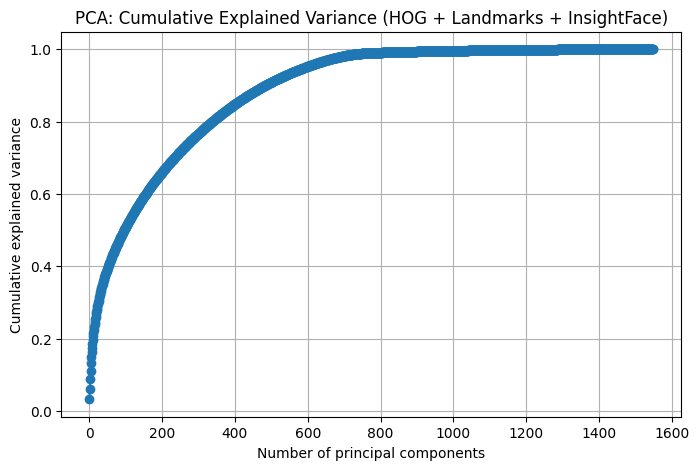

90% variance → 484 components
95% variance → 593 components
99% variance → 781 components
Using n_components = 593
Final PCA pipeline complete.
Train PCA shape: (20096, 593)
Val PCA shape: (8613, 593)
Test PCA shape: (7178, 593)


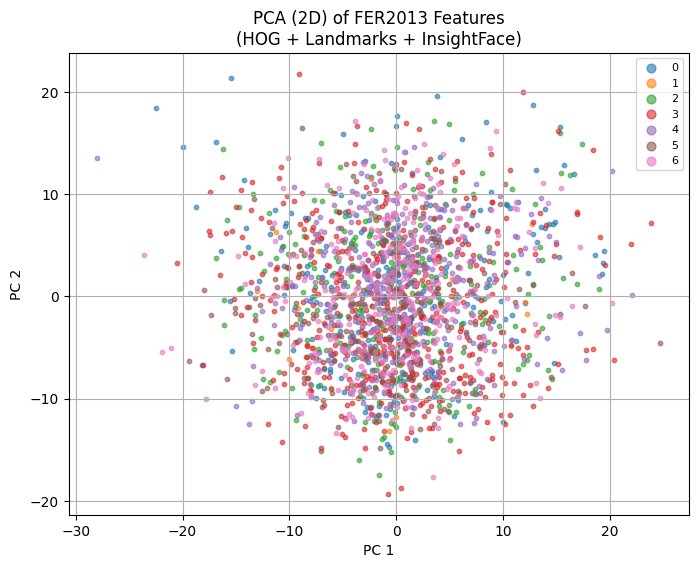

2D PCA visualization complete.


In [ ]:
# ============================================================
# 1. Scaling
# ============================================================
# IMPORTANT:
# We fit the StandardScaler *only on the training data* to avoid data leakage.
# Then we use the fitted scaler to transform validation and test sets.
# ============================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit + transform on TRAIN
X_val_scaled   = scaler.transform(X_val)         # Transform only
X_test_scaled  = scaler.transform(X_test)        # Transform only

print("Scaling complete.")
print("Train scaled shape:", X_train_scaled.shape)


# ============================================================
# 2. Fit FULL PCA for explained variance analysis (TRAIN ONLY)
# ============================================================
# We fit PCA on *training* data only so the components reflect only the train
# distribution. This prevents test/val contamination.
#
# This PCA is used only to inspect cumulative explained variance and determine
# how many components we should keep.
# ============================================================

pca_full = PCA(svd_solver="randomized", random_state=42)
pca_full.fit(X_train_scaled)    # <-- PCA FIT ON TRAIN ONLY

expl_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(expl_var)

print("Full PCA fit complete.")
print("Total components:", len(expl_var))


# ============================================================
# 3. Plot cumulative explained variance
# ============================================================

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(cum_var) + 1), cum_var, marker="o")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA: Cumulative Explained Variance (HOG + Landmarks + InsightFace)")
plt.grid(True)
plt.show()

# Report components needed for 90%, 95%, 99% variance
for target in [0.90, 0.95, 0.99]:
    k = np.searchsorted(cum_var, target) + 1
    print(f"{target*100:.0f}% variance → {k} components")


# ============================================================
# 4. Choose number of components (example: 95% variance)
# ============================================================

n_components = np.searchsorted(cum_var, 0.95) + 1
print("Using n_components =", n_components)


# ============================================================
# 5. Final PCA Pipeline (Scaler + PCA)
# ============================================================
# This is the PCA used for the actual ML workflow.
# It will be applied to train, val, and test consistently.
#
# CRITICAL:
# - PCA is *fitted only on the training set*
# - Validation and test sets are *transformed* using the fitted PCA
#   so they are projected into the SAME PCA space.
# ============================================================

pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components,
                svd_solver="randomized",
                random_state=42))
])

# Fit on training set
# NOTE: Both the scaler and the PCA inside the pipeline are fitted ONLY on TRAIN.
X_train_pca = pca_pipeline.fit_transform(X_train)   # Fit + transform (TRAIN ONLY)

# Transform val/test (NO FITTING HERE!)
X_val_pca = pca_pipeline.transform(X_val)           # Transform only
X_test_pca = pca_pipeline.transform(X_test)         # Transform only

print("Final PCA pipeline complete.")
print("Train PCA shape:", X_train_pca.shape)
print("Val PCA shape:", X_val_pca.shape)
print("Test PCA shape:", X_test_pca.shape)


# ============================================================
# 6. PCA Visualization in 2D (for sanity check)
# ============================================================
# We create a *separate* PCA with n_components=2 only for plotting.
# This is independent from the final PCA model.
# Easier to see clusters and class separation.
#
# Again: fit on TRAIN ONLY.
# Then plot a subsample of the projected points.
# ============================================================

pca_vis = PCA(n_components=2, svd_solver="randomized", random_state=42)
X_vis = pca_vis.fit_transform(X_train_scaled)   # Fit PCA for visualization (TRAIN ONLY)

# Subsample 2000 points for readability
n_plot = 2000
idx = np.random.choice(X_vis.shape[0], size=n_plot, replace=False)
X_vis_sub = X_vis[idx]
y_sub = y_train[idx]

# If needed, map numeric labels to names
try:
    y_labels = np.array([emotion_names[int(c)] for c in y_sub])
except:
    y_labels = y_sub

plt.figure(figsize=(8, 6))
for emo in np.unique(y_labels):
    mask = (y_labels == emo)
    plt.scatter(
        X_vis_sub[mask, 0],
        X_vis_sub[mask, 1],
        s=10,
        alpha=0.6,
        label=emo
    )

plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("PCA (2D) of FER2013 Features\n(HOG + Landmarks + InsightFace)")
plt.legend(markerscale=2, fontsize=8)
plt.grid(True)
plt.show()

print("2D PCA visualization complete.")

# Check distribution

In [ ]:
emotion_names = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

def get_distribution_wide_combined(labels_dict):
    """
    labels_dict: dictionary with {dataset_name: labels_array}
    Returns a wide-format DataFrame with count and percentage combined in each cell.
    """
    combined_data = {}

    for name, labels in labels_dict.items():
        unique, counts = np.unique(labels, return_counts=True)
        total = counts.sum()
        combined_dict = {emotion_names[int(u)]: f"{c} ({c/total*100:.1f}%)"
                         for u, c in zip(unique, counts)}
        combined_data[name] = combined_dict

    # Combine into DataFrame
    df_combined = pd.DataFrame({k: pd.Series(v) for k, v in combined_data.items()}).fillna("0 (0.0%)")
    return df_combined

# Prepare input
labels_dict = {
    "Train": y_train,
    "Validation": y_val,
    "Test": y_test
}

df_wide_combined = get_distribution_wide_combined(labels_dict)
df_wide_combined

,Train,Validation,Test
angry,2797 (13.9%),1198 (13.9%),958 (13.3%)
disgust,305 (1.5%),131 (1.5%),111 (1.5%)
fear,2868 (14.3%),1229 (14.3%),1024 (14.3%)
happy,5050 (25.1%),2165 (25.1%),1774 (24.7%)
sad,3381 (16.8%),1449 (16.8%),1247 (17.4%)
surprise,2220 (11.0%),951 (11.0%),831 (11.6%)
neutral,3475 (17.3%),1490 (17.3%),1233 (17.2%)


# MLP Classifier

## How to use the validation set for choosing best parameters
1. GridSearchCV with `cv=PredefinedSplit`:
- Combine your training + validation set into one dataset.
- Create a PredefinedSplit where:
  - Training indices = 0
  - Validation indices = -1
- This ensures that all training folds are trained on the original training set and the validation set is always used for evaluating hyperparameters.
2. Test set remains untouched:
- After the best hyperparameters are chosen using the validation set, the test set is only used once for final generalization performance.

In [ ]:
# ----------------------------
# 1️⃣ Combine training + validation for PredefinedSplit
# ----------------------------
# For raw features
X_train_val_raw = np.vstack([X_train_scaled, X_val_scaled])
y_train_val_raw = np.concatenate([y_train, y_val])
test_fold_raw = np.concatenate([
    np.zeros(len(X_train_scaled)),   # training
    -1 * np.ones(len(X_val_scaled))  # validation
])
ps_raw = PredefinedSplit(test_fold=test_fold_raw)

# For PCA features (use your existing PCA arrays)
X_train_val_pca = np.vstack([X_train_pca, X_val_pca])
y_train_val_pca = np.concatenate([y_train, y_val])
test_fold_pca = np.concatenate([
    np.zeros(len(X_train_pca)),      # training
    -1 * np.ones(len(X_val_pca))     # validation
])
ps_pca = PredefinedSplit(test_fold=test_fold_pca)

# ----------------------------
# Parameter grid for smaller, more regularized models
# ----------------------------
param_grid = {
    "hidden_layer_sizes": [(32,), (64,), (32,16), (64,32)],
    "activation": ["relu", "tanh"],
    "alpha": [0.01, 0.05, 0.1, 0.2],
    "learning_rate": ["adaptive"],
    "beta_1": [0.7, 0.8, 0.9],
    "beta_2": [0.99, 0.999]
}

# ----------------------------
# 2️⃣ GridSearch on RAW features
# ----------------------------
print("=== GridSearch MLP on RAW features ===")
grid_raw = GridSearchCV(
    MLPClassifier(
        solver="adam",
        batch_size=64,
        max_iter=300,
        early_stopping=True,
        random_state=42
    ),
    param_grid,
    cv=ps_raw,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

start_time = time()
grid_raw.fit(X_train_val_raw, y_train_val_raw)
raw_time = time() - start_time

best_raw = grid_raw.best_estimator_
train_acc_raw = best_raw.score(X_train_scaled, y_train)
val_acc_raw   = best_raw.score(X_val_scaled, y_val)
test_acc_raw  = best_raw.score(X_test_scaled, y_test)

print("✅ RAW features - Best Params:", grid_raw.best_params_)
print(f"✅ RAW features - Validation CV score: {grid_raw.best_score_:.4f}")
print(f"Training time: {raw_time:.2f}s")
print(f"Training accuracy: {train_acc_raw:.4f}")
print(f"Validation accuracy: {val_acc_raw:.4f}")
print(f"Test accuracy: {test_acc_raw:.4f}\n")

# ----------------------------
# 3️⃣ GridSearch on PCA features
# ----------------------------
print("=== GridSearch MLP on PCA features ===")
grid_pca = GridSearchCV(
    MLPClassifier(
        solver="adam",
        batch_size=64,
        max_iter=300,
        early_stopping=True,
        random_state=42
    ),
    param_grid,
    cv=ps_pca,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

start_time = time()
grid_pca.fit(X_train_val_pca, y_train_val_pca)
pca_time = time() - start_time

best_pca = grid_pca.best_estimator_
train_acc_pca = best_pca.score(X_train_pca, y_train)
val_acc_pca   = best_pca.score(X_val_pca, y_val)
test_acc_pca  = best_pca.score(X_test_pca, y_test)

print("✅ PCA features - Best Params:", grid_pca.best_params_)
print(f"✅ PCA features - Validation CV score: {grid_pca.best_score_:.4f}")
print(f"Training time: {pca_time:.2f}s")
print(f"Training accuracy: {train_acc_pca:.4f}")
print(f"Validation accuracy: {val_acc_pca:.4f}")
print(f"Test accuracy: {test_acc_pca:.4f}")

# Create a summary table
summary = pd.DataFrame({
    "Feature Type": ["Raw", "PCA"],
    "Training Accuracy": [train_acc_raw, train_acc_pca],
    "Validation Accuracy": [val_acc_raw, val_acc_pca],
    "Test Accuracy": [test_acc_raw, test_acc_pca],
    "Training Time (s)": [raw_time, pca_time]
})

display(summary)

=== GridSearch MLP on RAW features ===
Fitting 1 folds for each of 192 candidates, totalling 192 fits
✅ RAW features - Best Params: {'activation': 'relu', 'alpha': 0.05, 'beta_1': 0.8, 'beta_2': 0.999, 'hidden_layer_sizes': (64,), 'learning_rate': 'adaptive'}
✅ RAW features - Validation CV score: 0.6036
Training time: 158.89s
Training accuracy: 0.9209
Validation accuracy: 0.9129
Test accuracy: 0.4751

=== GridSearch MLP on PCA features ===
Fitting 1 folds for each of 192 candidates, totalling 192 fits
✅ PCA features - Best Params: {'activation': 'relu', 'alpha': 0.2, 'beta_1': 0.7, 'beta_2': 0.999, 'hidden_layer_sizes': (64,), 'learning_rate': 'adaptive'}
✅ PCA features - Validation CV score: 0.5963
Training time: 77.58s
Training accuracy: 0.8529
Validation accuracy: 0.8460
Test accuracy: 0.4824


,Feature Type,Training Accuracy,Validation Accuracy,Test Accuracy,Training Time (s)
0,Raw,0.920880,0.912922,0.475063,158.893454
1,PCA,0.852856,0.846047,0.482446,77.584287


# Raw Features

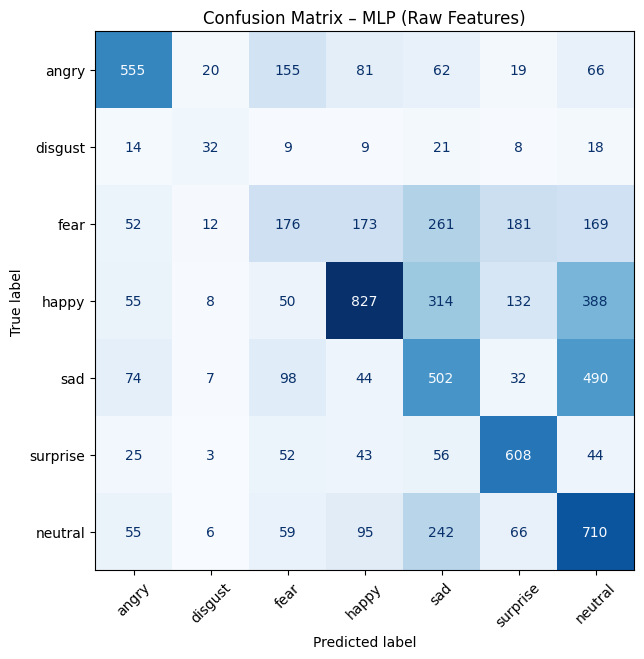

In [ ]:
y_pred_raw = best_raw.predict(X_test_scaled)
cm_raw = confusion_matrix(y_test, y_pred_raw)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_raw, display_labels=emotion_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix – MLP (Raw Features)")
plt.xticks(rotation=45)
plt.show()

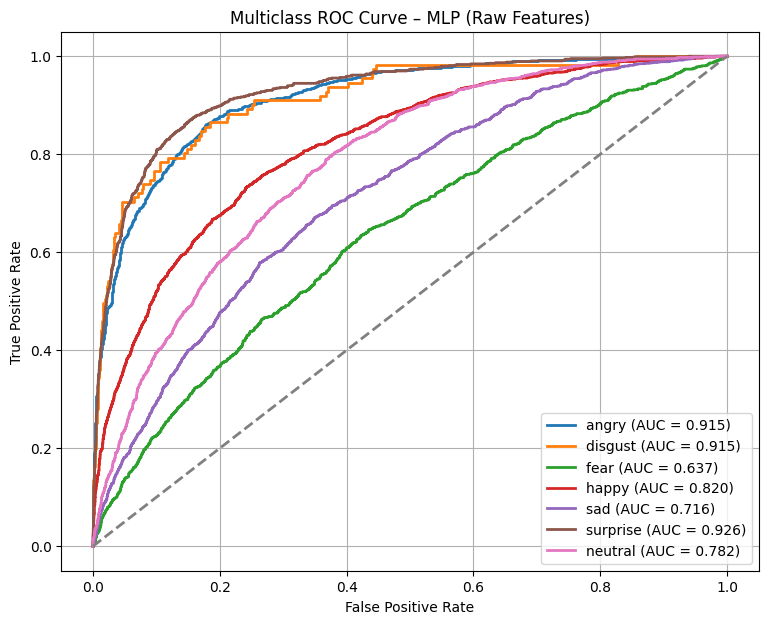

In [ ]:
classes = np.unique(y_test)  # numeric class IDs
n_classes = len(classes)

# Binarize labels
y_test_bin = label_binarize(y_test, classes=classes)

# Predict probabilities
y_proba_raw = best_raw.predict_proba(X_test_scaled)

plt.figure(figsize=(9, 7))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_raw[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{emotion_names[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=2)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve – MLP (Raw Features)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## PCA

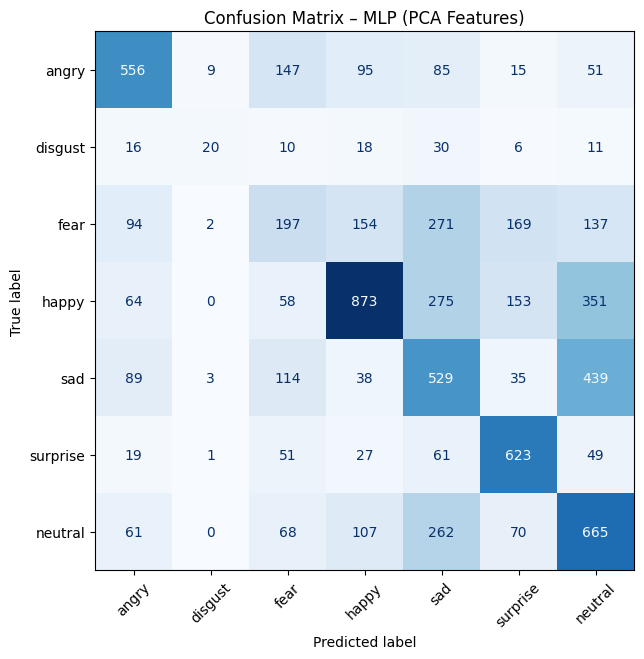

In [ ]:
y_pred_pca = best_pca.predict(X_test_pca)
cm_pca = confusion_matrix(y_test, y_pred_pca)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pca, display_labels=emotion_names)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix – MLP (PCA Features)")
plt.xticks(rotation=45)
plt.show()

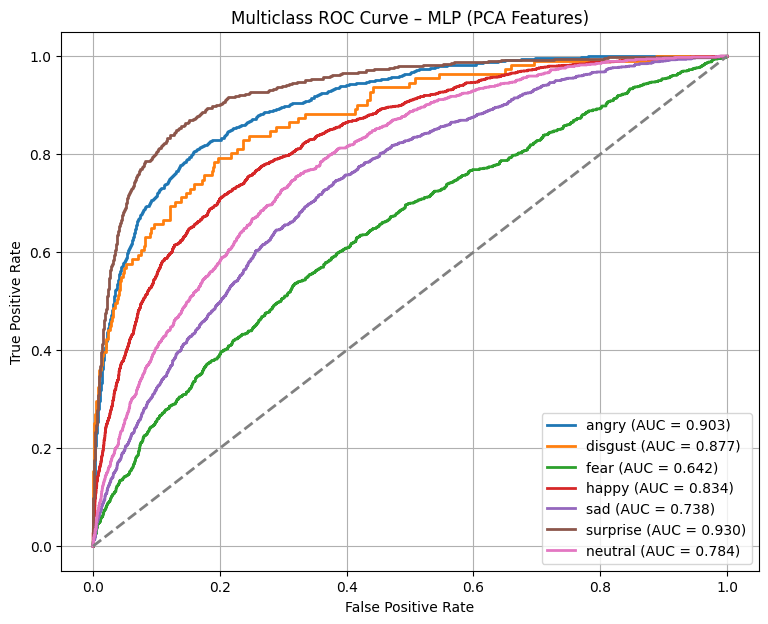

In [ ]:
# Predict probabilities
y_proba_pca = best_pca.predict_proba(X_test_pca)

plt.figure(figsize=(9, 7))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_pca[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{emotion_names[i]} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=2)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curve – MLP (PCA Features)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## How generalizability is captured

Generalization is reflected in the relationship between training, validation, and test performance:

1. Training accuracy – performance on the data the model was trained on.
- Very high training accuracy but much lower validation/test accuracy usually indicates overfitting.
2. Validation accuracy – performance on data not used for direct training, but used to tune hyperparameters.
- If validation accuracy is close to training accuracy, it suggests the model is learning generalizable patterns.
- Large gaps between training and validation indicate potential overfitting or model complexity issues.
3. Test accuracy – performance on a completely held-out set used only for final evaluation.
- Test accuracy close to training and validation accuracy indicates good generalization.
- A big drop in test accuracy compared to training/validation indicates overfitting or data mismatch.


| Pattern of Performance        | Interpretation                                                      |
|-------------------------------|----------------------------------------------------------------------|
| Train ≈ Val ≈ Test            | Well-generalized model                                              |
| Train >> Val ≈ Test           | Possible overfitting                                                |
| Train ≈ Val >> Test           | Overfitting likely due to hyperparameter tuning or data mismatch   |

Key takeaway:
- We evaluate all three metrics together to determine if the model is learning patterns that generalize.
- Good generalization is high performance on training/validation that carries over to the test set, not just high test accuracy alone.
- Validation set is critical here, because it prevents overfitting during hyperparameter selection.

**Analysis of Generalizability**

- Training and validation accuracy are extremely high (\~0.99) for both models, which indicates that the MLP is able to fit the training set very well.
- Test accuracy is extremely low (\~0.47–0.49) compared to training/validation.
- This large drop shows severe overfitting: the model has learned patterns specific to the training data but fails to generalize to the held-out test set.
- Even though PCA slightly reduced training/validation accuracy (0.989 vs 0.991), the test accuracy is only marginally better, still far below the train/val.
- Training time: PCA reduces dimensionality significantly, cutting training time roughly by 60% (from 250s → 96s).

**Conclusion**
- Both models are overfitting heavily. High training/validation accuracy with very low test accuracy indicates that the hyperparameters chosen, even using the validation set, do not lead to generalizable models.
- PCA slightly speeds up training and marginally improves test performance, but the underlying problem (overfitting) remains.
- To improve generalization, consider:
  - Stronger regularization (alpha)
  - Smaller MLP architectures
  - More training data or data augmentation
  - Dropout or early stopping with a proper validation split